# EDA Telco Customer Churn

## 0) Setup

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("clean_WA_Fn-UseC_-Telco-Customer-Churn.csv")

OUT_DIR = Path("eda_outputs")
PLOTS_DIR = OUT_DIR / "plots"
OUT_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

TARGET_COL = "Churn"
ID_COL = "customerID"


def save_fig(filename: str) -> None:
    """Save the current plot to the plots folder."""
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{filename}.png", dpi=180, bbox_inches="tight")
    plt.close()

## 1) Load Data and Basic Info 

In [21]:
print("1) Loading data...")
df = pd.read_csv(DATA_PATH)

print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

# Common issue in this dataset is TotalCharges sometimes loads as text
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("\nBasic info:")
df.info()

# Check ID uniqueness
if ID_COL in df.columns:
    print(f"\nUnique {ID_COL} values:", df[ID_COL].nunique(), "out of", len(df), "rows")

1) Loading data...

Dataset shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

 

## 2) Missing Values

In [22]:
print("\n2) Missing values:")

missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)

missing_table = (
    pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
    .sort_values("missing_count", ascending=False)
)

print("\nTop missing columns:")
print(missing_table.head(10))

missing_table.to_csv(OUT_DIR / "missing_values_report.csv")


2) Missing values:

Top missing columns:
                missing_count  missing_pct
TotalCharges               11         0.16
gender                      0         0.00
SeniorCitizen               0         0.00
Partner                     0         0.00
customerID                  0         0.00
Dependents                  0         0.00
tenure                      0         0.00
MultipleLines               0         0.00
PhoneService                0         0.00
OnlineSecurity              0         0.00


## 3) TARGET VARIABLE (CHURN) DISTRIBUTION


3) Target distribution:

Churn distribution:
       count    pct
Churn              
No      5174  73.46
Yes     1869  26.54


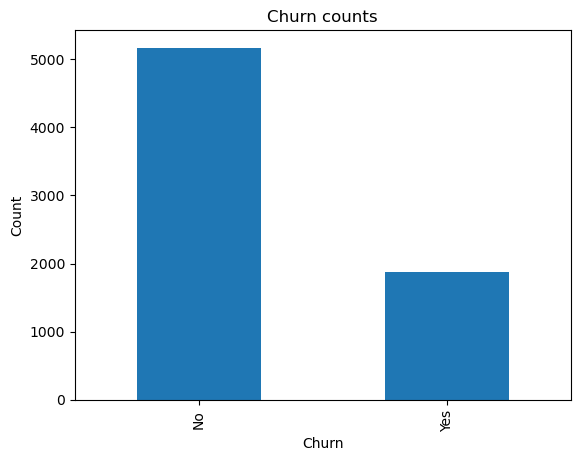

In [23]:
print("\n3) Target distribution:")

target_counts = df[TARGET_COL].value_counts(dropna=False)
target_pct = (target_counts / len(df) * 100).round(2)
target_table = pd.DataFrame({"count": target_counts, "pct": target_pct})

print("\nChurn distribution:")
print(target_table)

target_table.to_csv(OUT_DIR / "target_distribution.csv")

plt.figure()
target_counts.plot(kind="bar")
plt.title("Churn counts")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()
save_fig("target_churn_counts")

## 4) SPLIT NUMERIC VS CATEGORICAL COLUMNS


In [24]:
print("\n4) Splitting numeric vs categorical columns:")

numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=["number"]).columns.tolist()

# Remove target and ID from feature lists
if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)
if TARGET_COL in categorical_cols:
    categorical_cols.remove(TARGET_COL)

if ID_COL in categorical_cols:
    categorical_cols.remove(ID_COL)

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

pd.DataFrame({"numeric_columns": pd.Series(numeric_cols)}).to_csv(OUT_DIR / "numeric_columns.csv", index=False)
pd.DataFrame({"categorical_columns": pd.Series(categorical_cols)}).to_csv(
    OUT_DIR / "categorical_columns.csv", index=False
)




4) Splitting numeric vs categorical columns:
Numeric columns (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 5) NUMERIC FEATURES: SUMMARY + PLOTS


5) Numeric summaries and plots:

Numeric summary (head):
                 count         mean          std    min     25%       50%  \
SeniorCitizen   7043.0     0.162147     0.368612   0.00    0.00     0.000   
tenure          7043.0    32.371149    24.559481   0.00    9.00    29.000   
MonthlyCharges  7043.0    64.761692    30.090047  18.25   35.50    70.350   
TotalCharges    7032.0  2283.300441  2266.771362  18.80  401.45  1397.475   

                      75%      max  
SeniorCitizen      0.0000     1.00  
tenure            55.0000    72.00  
MonthlyCharges    89.8500   118.75  
TotalCharges    3794.7375  8684.80  


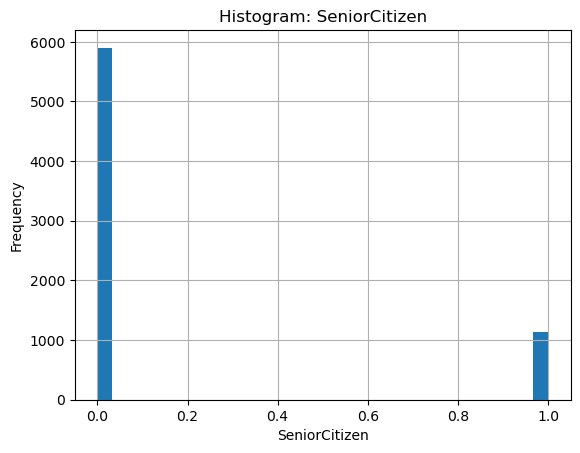

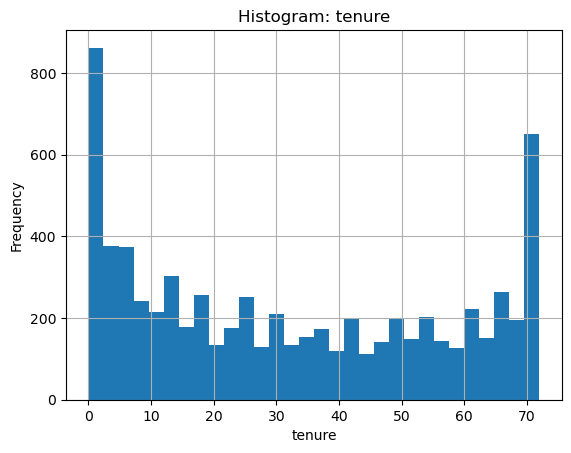

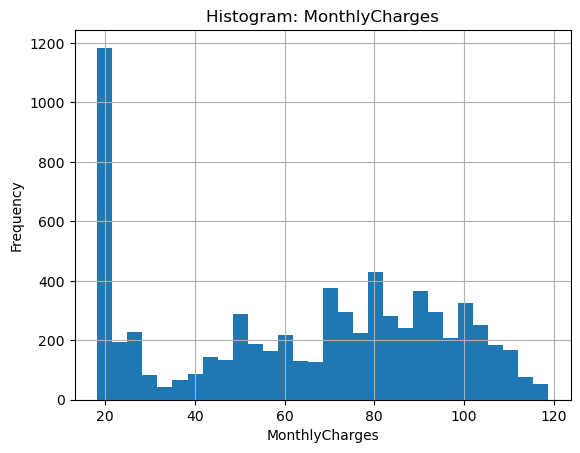

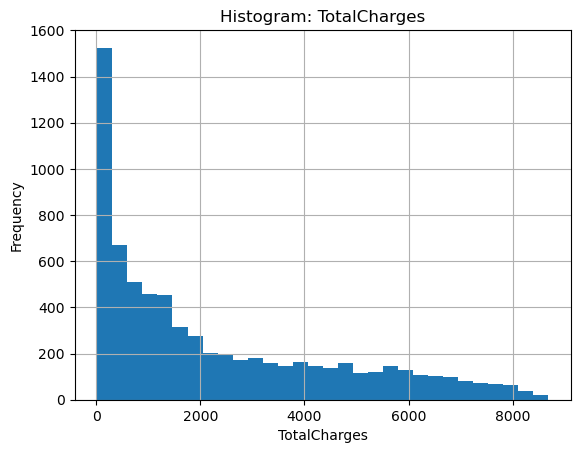

<Figure size 640x480 with 0 Axes>

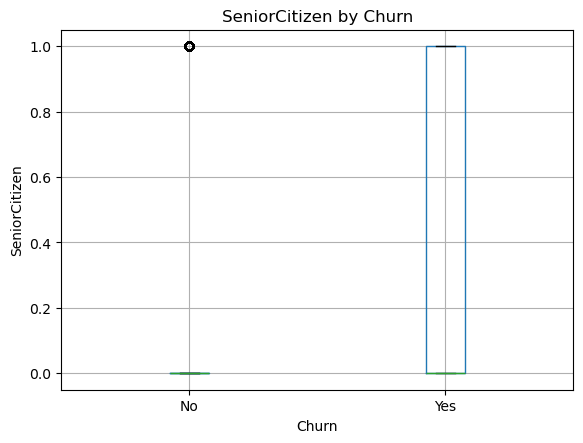

<Figure size 640x480 with 0 Axes>

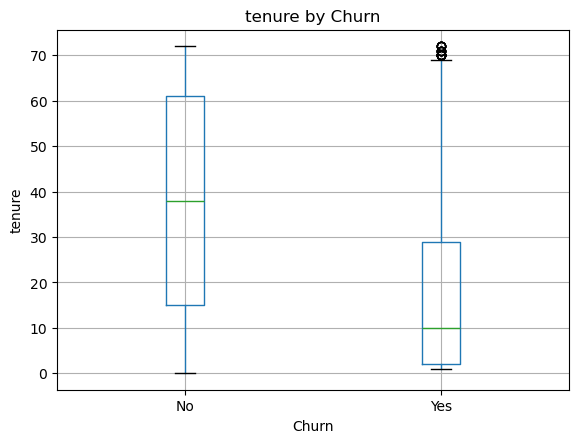

<Figure size 640x480 with 0 Axes>

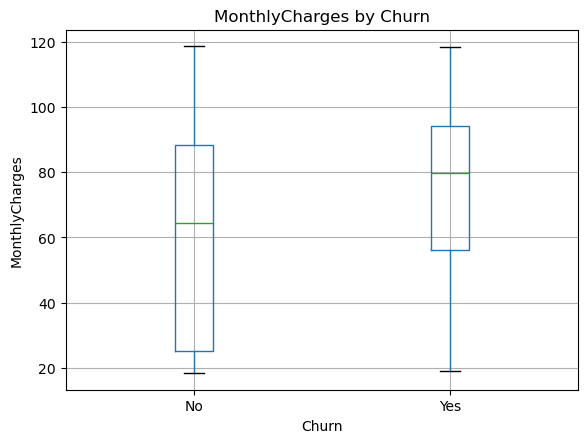

<Figure size 640x480 with 0 Axes>

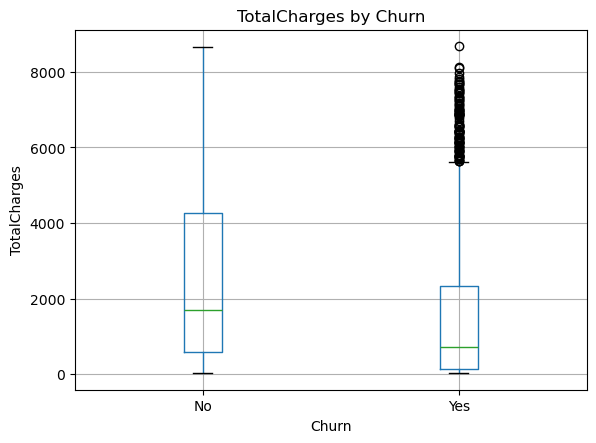

In [25]:
print("\n5) Numeric summaries and plots:")

if len(numeric_cols) > 0:
    numeric_summary = df[numeric_cols].describe().T
    print("\nNumeric summary (head):")
    print(numeric_summary.head())

    numeric_summary.to_csv(OUT_DIR / "numeric_summary.csv")

    # Histograms
    for col in numeric_cols:
        plt.figure()
        df[col].hist(bins=30)
        plt.title(f"Histogram: {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()
        save_fig(f"hist_{col}")

    # Boxplots by Churn
    for col in numeric_cols:
        plt.figure()
        df.boxplot(column=col, by=TARGET_COL)
        plt.title(f"{col} by {TARGET_COL}")
        plt.suptitle("")  # remove automatic subtitle
        plt.xlabel(TARGET_COL)
        plt.ylabel(col)
        plt.show()
        save_fig(f"box_{col}_by_churn")
else:
    print("No numeric columns found.")

## 6) CATEGORICAL FEATURES: VALUE COUNTS + CHURN RATES


6) Categorical summaries and churn rates:


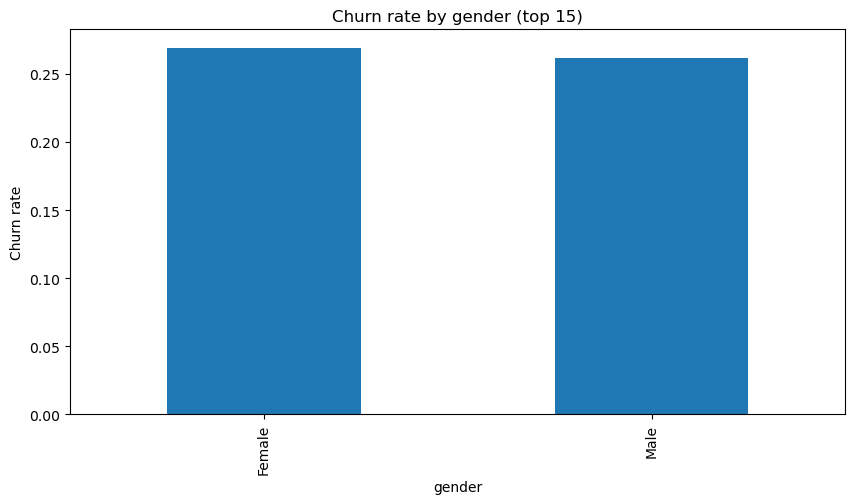

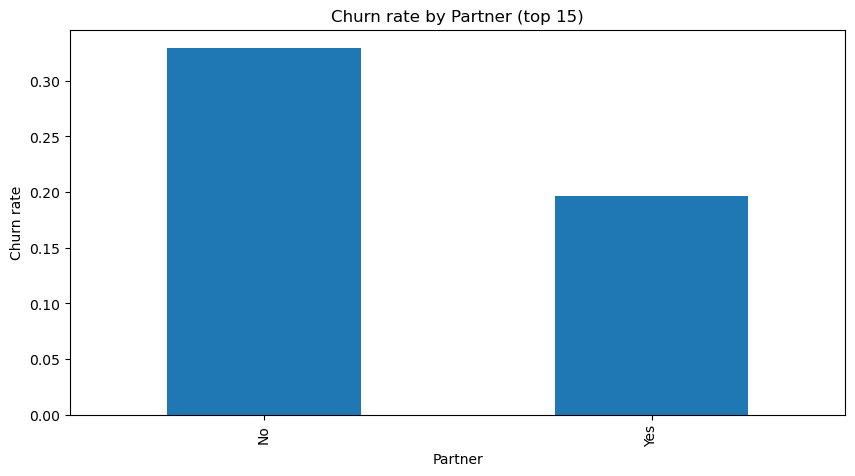

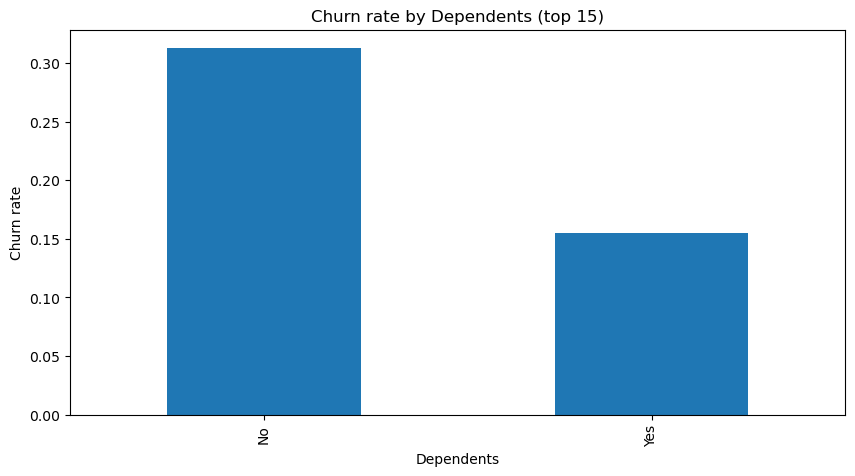

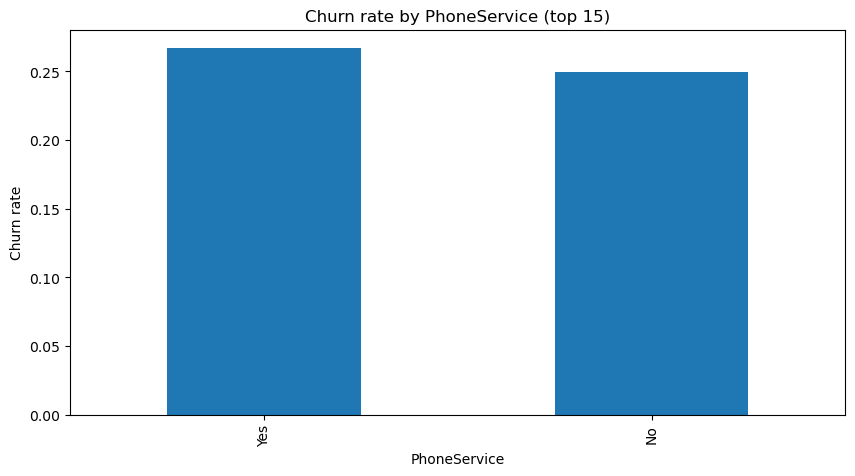

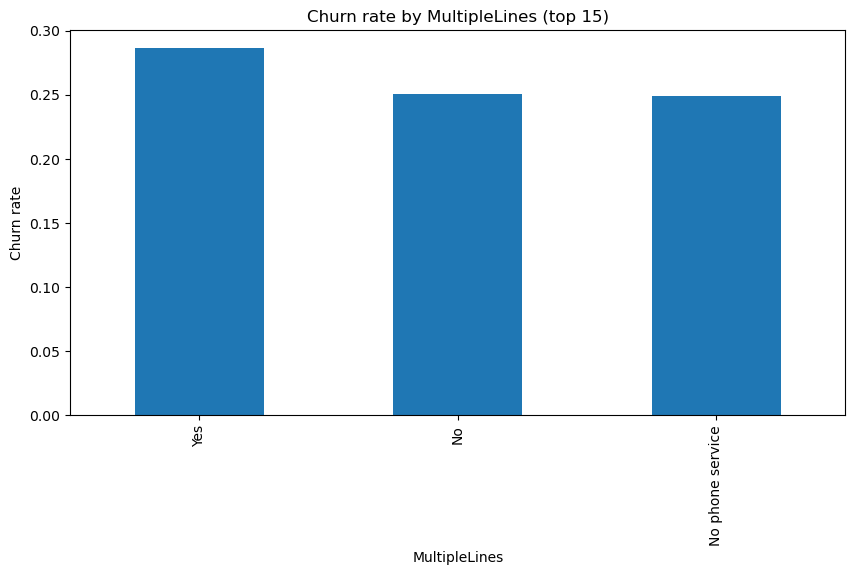

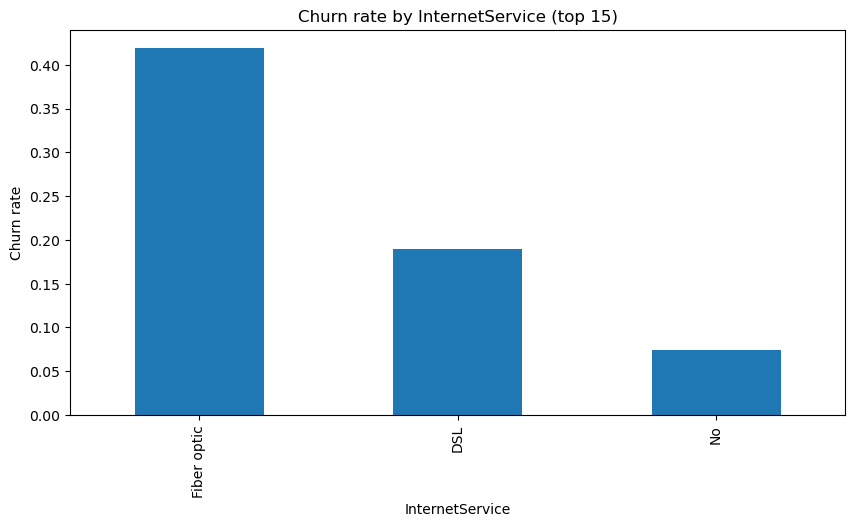

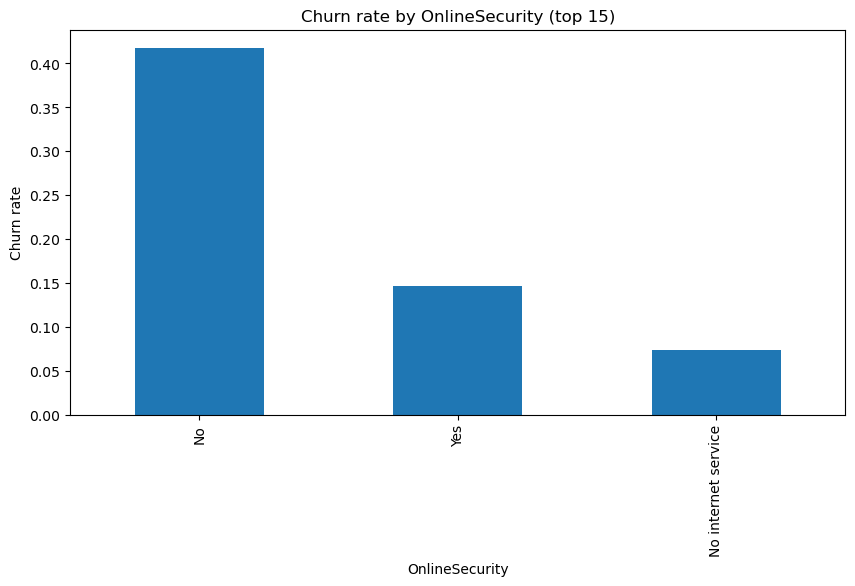

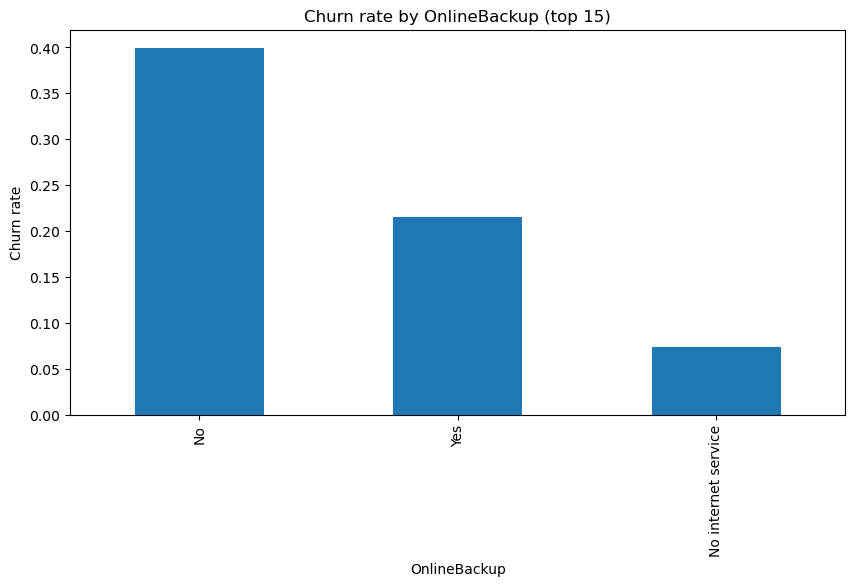

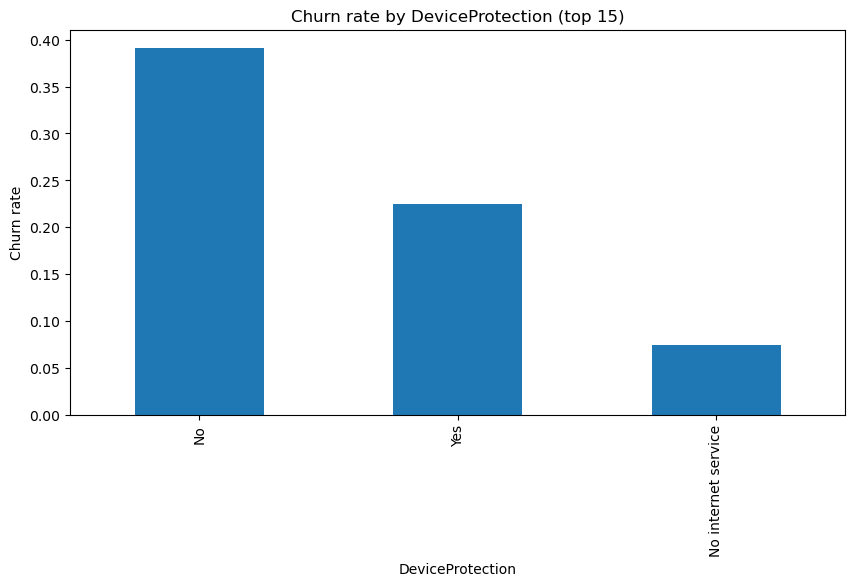

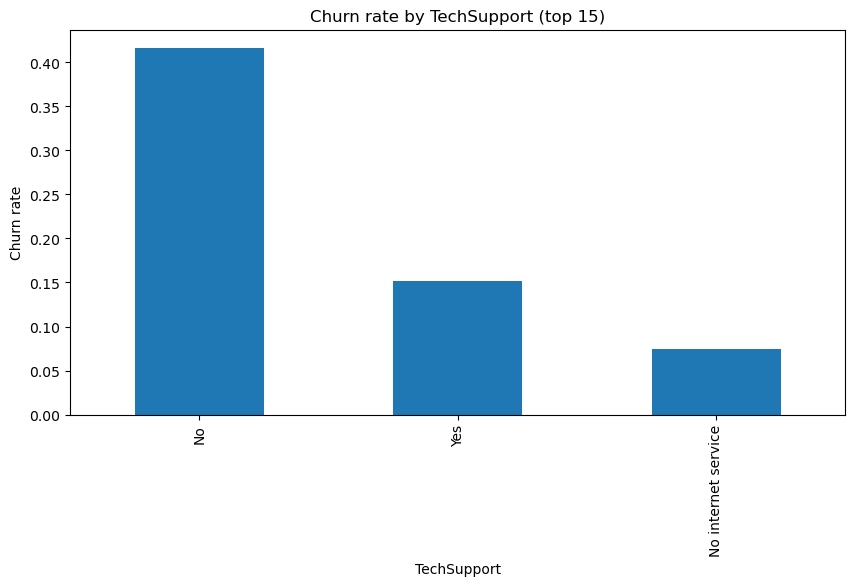

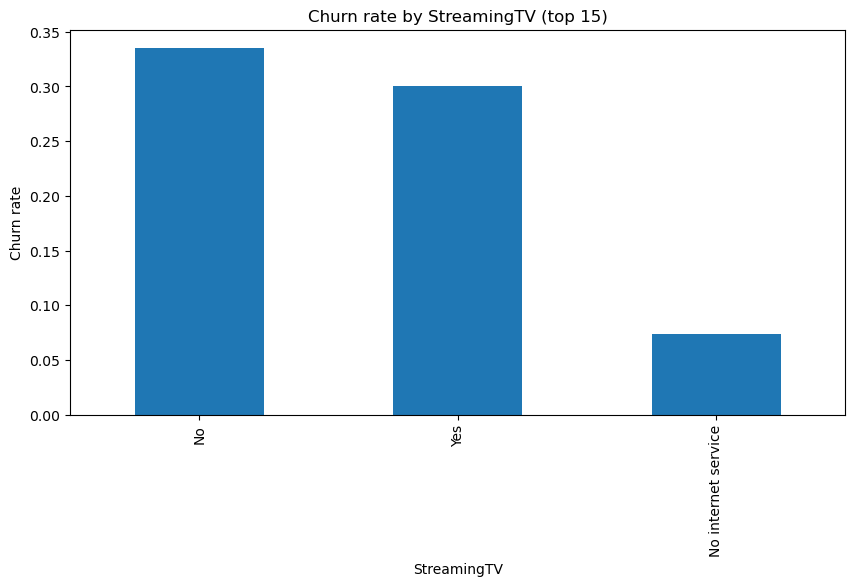

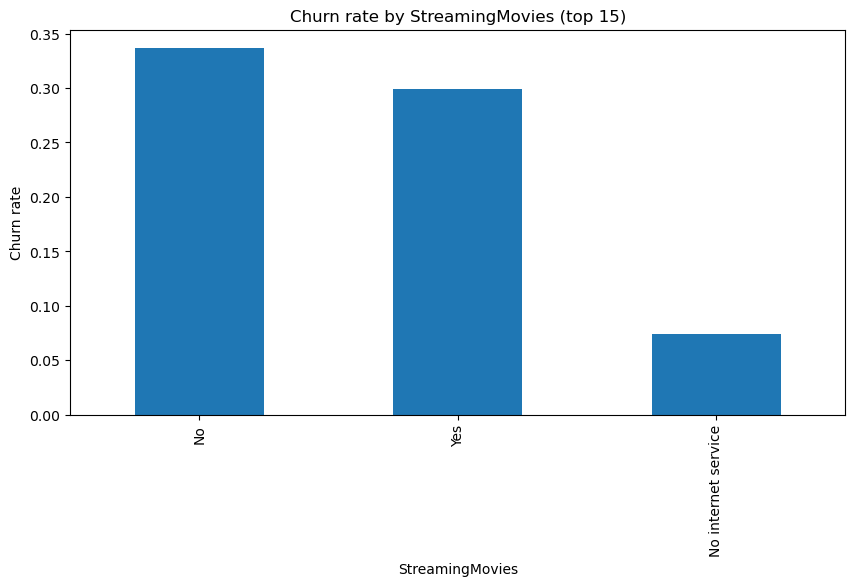

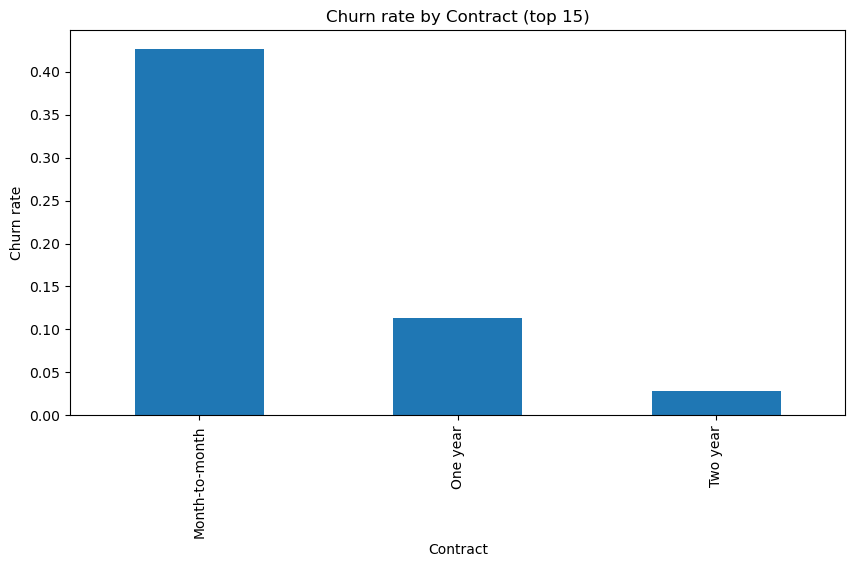

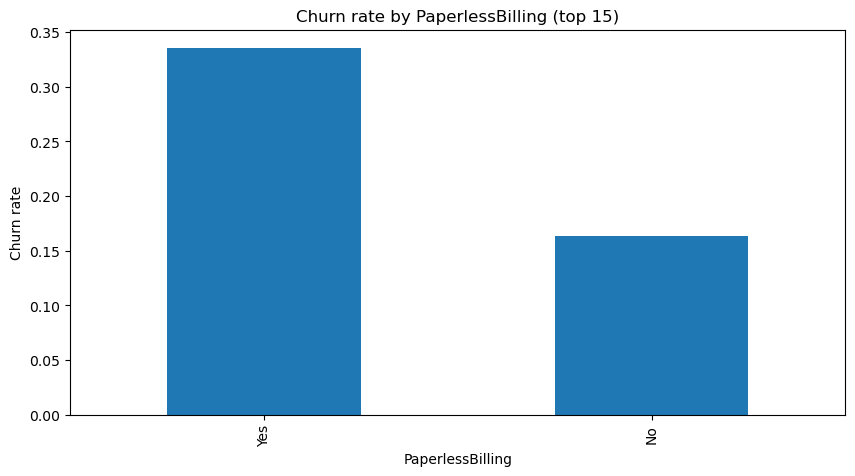

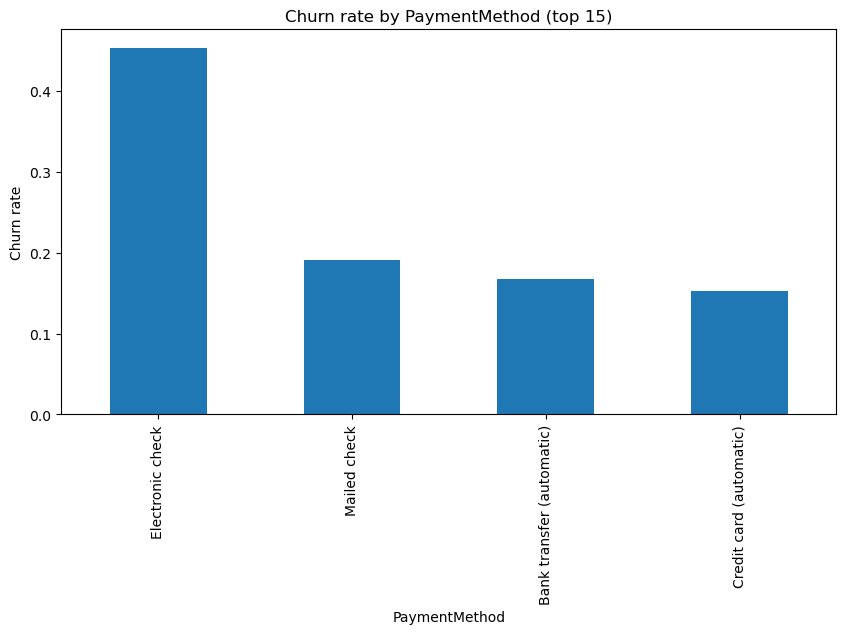

In [26]:
print("\n6) Categorical summaries and churn rates:")

churn_tables_dir = OUT_DIR / "churn_rate_tables"
churn_tables_dir.mkdir(exist_ok=True, parents=True)

for col in categorical_cols:
    # Value counts (including missing)
    vc = df[col].value_counts(dropna=False)
    vc.to_csv(OUT_DIR / f"value_counts_{col}.csv")

    # Churn rate per category level
    temp = df[[col, TARGET_COL]].dropna()
    ct = pd.crosstab(temp[col], temp[TARGET_COL])

    # Ensure both columns exist
    for cls in ["No", "Yes"]:
        if cls not in ct.columns:
            ct[cls] = 0

    ct = ct[["No", "Yes"]]
    ct["total"] = ct["No"] + ct["Yes"]
    ct["churn_rate"] = (ct["Yes"] / ct["total"]).replace([np.inf, -np.inf], np.nan)

    ct_sorted = ct.sort_values("churn_rate", ascending=False)
    ct_sorted.to_csv(churn_tables_dir / f"churn_rate_{col}.csv")

    # Plot top 15 categories by churn rate (for readability)
    top = ct_sorted.head(15)

    plt.figure(figsize=(10, 5))
    top["churn_rate"].plot(kind="bar")
    plt.title(f"Churn rate by {col} (top 15)")
    plt.xlabel(col)
    plt.ylabel("Churn rate")
    plt.show()
    save_fig(f"churn_rate_by_{col}")


## 7) SIMPLE CORRELATION (NUMERIC ONLY)


7) Numeric correlation:


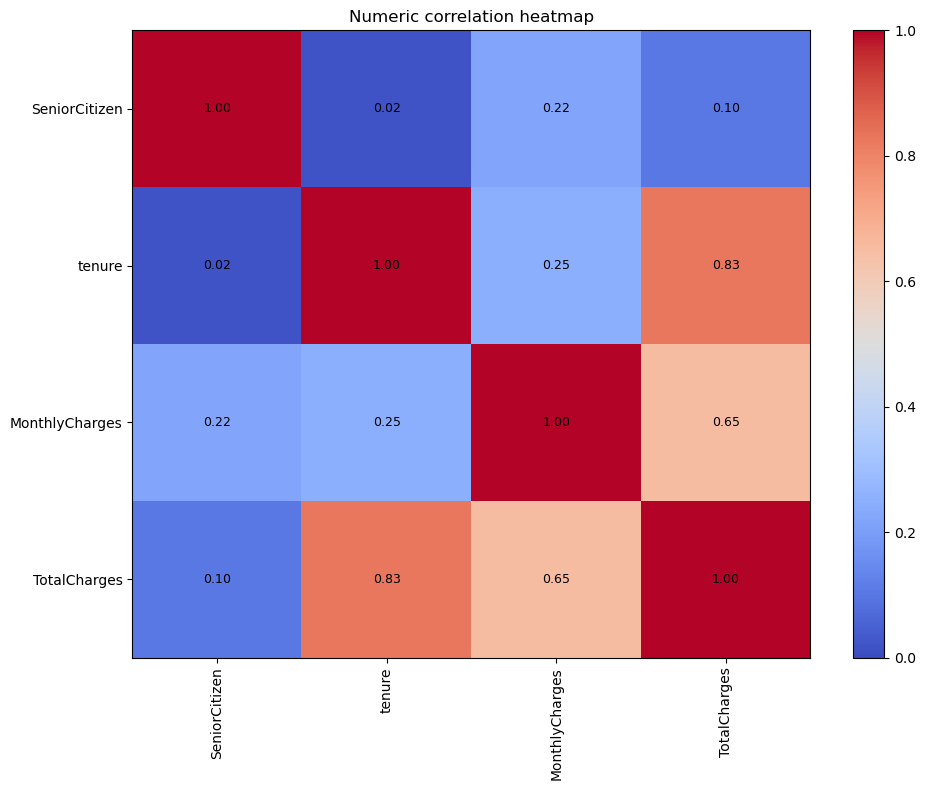


EDA complete!


In [ ]:
print("\n7) Numeric correlation:")

if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr(numeric_only=True)
    corr.to_csv(OUT_DIR / "numeric_correlation.csv")

    plt.figure(figsize=(10, 8))

    # Heatmap with different color map
    im = plt.imshow(corr, aspect="auto", vmin=0, vmax=1, cmap="coolwarm")
    plt.title("Numeric correlation heatmap")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar(im)

    # Add correlation values inside each cell
    for i in range(corr.shape[0]):
        for j in range(corr.shape[1]):
            val = corr.iloc[i, j]
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

    plt.tight_layout()\
    plt.show()

    save_fig("numeric_corr_heatmap")

else:
    print("Not enough numeric columns for correlation.")

print("\nEDA complete!")